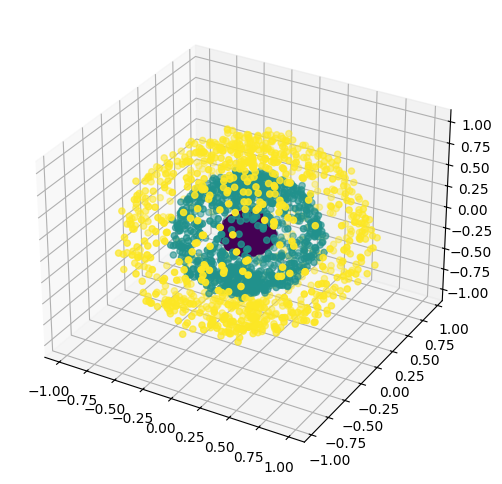

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def make_sphere(n_samples=1000, radius=1.0, noise=0.0):
    phi = np.random.uniform(0, 2*np.pi, n_samples)
    theta = np.random.uniform(0, np.pi, n_samples)
    x = radius * np.sin(theta) * np.cos(phi)
    y = radius * np.sin(theta) * np.sin(phi)
    z = radius * np.cos(theta)
    X = np.column_stack((x, y, z))
    if noise > 0:
        X += np.random.normal(scale=noise, size=X.shape)
    return X


X0 = make_sphere(n_samples=1000, radius=0.9, noise=0.05)
X = np.vstack([X0*0.2, X0*0.6, X0])
ones = np.ones(X0.shape[0])
y = np.hstack([0*ones, ones, 2*ones])
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:,0], X[:,1], X[:,2], c = y)
plt.show()

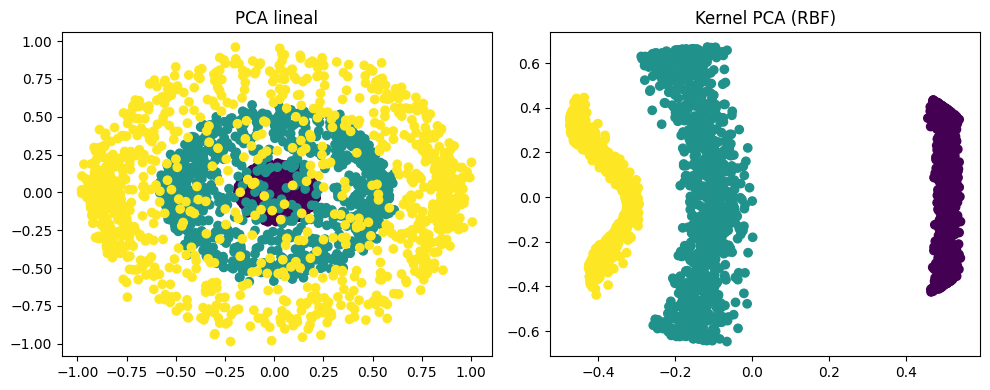

In [2]:
from sklearn.decomposition import PCA, KernelPCA


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
kpca = KernelPCA(n_components=2, kernel='rbf', gamma=5)
X_kpca = kpca.fit_transform(X)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y)
axes[0].set_title("PCA lineal")
axes[1].scatter(X_kpca[:, 0], X_kpca[:, 1], c=y)
axes[1].set_title("Kernel PCA (RBF)")
plt.tight_layout()
plt.show()

---
# MDS (Multidimensional scaling)
## Ejemplo de uso geográfico de MDS
- Diapositiva 41/94.

/opt/homebrew/Caskroom/miniconda/base/envs/ml3/lib/python3.13/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


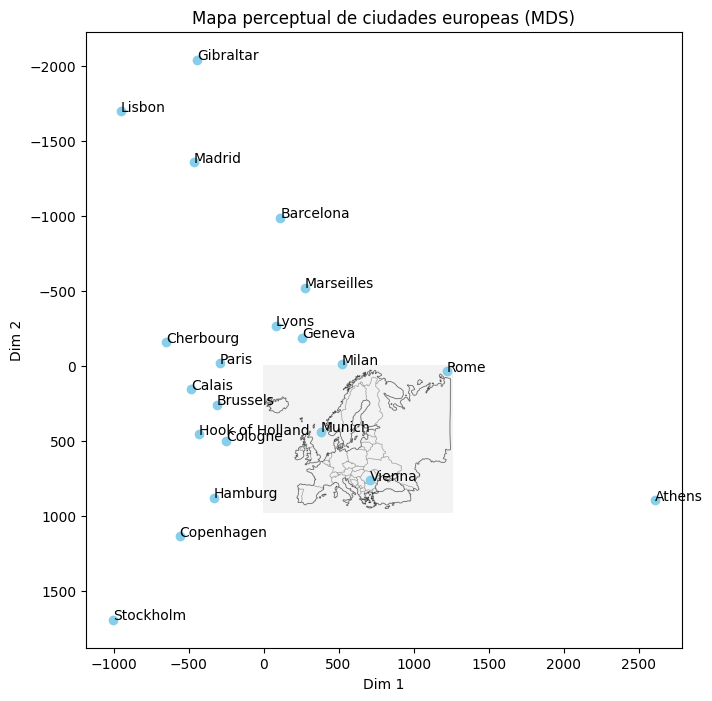

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import MDS
import cv2


img = cv2.imread("mapa_europa.jpg", flags=(cv2.IMREAD_GRAYSCALE))
df = pd.read_csv("eurodist.csv", index_col=0)
D = df.values
cities = df.index
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
coords = mds.fit_transform(D)
plt.figure(figsize=(10, 8))
plt.imshow(img, cmap="gray")
plt.scatter(coords[:, 0], coords[:, 1], color="skyblue")
for i, city in enumerate(cities):
    plt.text(coords[i, 0], coords[i, 1], city)
    plt.title("Mapa perceptual de ciudades europeas (MDS)")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
plt.savefig("ciudades.svg")
plt.show()

## Ejemplo de uso de MDS en marketing
- Diapositiva 42/94.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import MDS


productos = ["CocaCola", "Pepsi", "Café", "Zumo", "Agua"]
Similitudes = np.array([[9, 8, 3, 4, 2],[8, 9, 3, 4, 2],
    [3, 3, 9, 5, 4],[4, 4, 5, 9, 6],[2, 2, 4, 6, 9]])

max_sim = Similitudes.max()
Distancias = max_sim - Similitudes
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
coords = mds.fit_transform(Distancias)

plt.figure(figsize=(8,6))
plt.scatter(coords[:,0], coords[:,1], c="skyblue", s=200)
plt.title("Mapa perceptual de productos (MDS)", fontsize=14)
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
for i, prod in enumerate(productos):
    plt.text(coords[i,0]+0.05, coords[i,1], prod, fontsize=12)
plt.show()